# Notebook-base — Holt-Winters

### Informações do Grupo

##### Grupo: 1

Base: ``bitcoin.xlsx`` (pasta ``grupo1``) — série **diária** de preços do bitcoin, com a coluna de data ``timeOpen``
(epoch em **milissegundos**).

Alvo: ``priceClose`` (preço de fechamento diário). O Holt-Winters do notebook-base é **mensal**, então a série
diária é agregada por mês — média dos fechamentos do mês (``resample('MS').mean()``), o que também elimina as
23 datas ausentes do calendário (dias sem negociação).

- Granularidade: ``mensal (MS — início do mês)`` → 98 observações, de 2018-08 a 2026-09
- Random State (seed): ``42`` (o Holt-Winters é determinístico; a seed só é fixada por reprodutibilidade)
- Treino-teste: ``walk-forward com janela expansiva, horizonte de 12 meses e 3 origens; a última origem equivale ao hold-out dos últimos 12 meses``
- Sazonalidade: ``a base NÃO tem ciclo anual (F_sazonal = 0,00 na T05; gamma = 0 nos ajustes) -> SEASONAL = None``


## Importações e Configurações Padrão 

In [1]:
import itertools
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf

warnings.filterwarnings('ignore')

In [2]:
DATA_FILENAME = 'bitcoin.xlsx'
DATA_PATH = '.'                 # pasta onde está o arquivo (o notebook fica ao lado da base, em grupo1/)
DATE_COLUMN = 'timeOpen'        # coluna de data: epoch em MILISSEGUNDOS (ex.: 1534939200000)
DATE_UNIT = 'ms'                # unidade do epoch -> pd.to_datetime(df[DATE_COLUMN], unit=DATE_UNIT)
TARGET_COLUMN = 'priceClose'    # alvo: preço de fechamento diário do bitcoin
AGGREGATION = 'mean'            # agregação dos dias de cada mês: 'mean' (preço médio) ou 'last' (fechamento do mês)
FREQUENCY = 'MS'                # mensal, início do mês
SEED = 42
np.random.seed(SEED)

# Validação temporal (walk-forward)
HORIZON = 12                    # horizonte de previsão unificado (meses)
N_ORIGINS = 3                   # nº de origens de teste
ORIGIN_STEP = 12                # distância entre origens (= HORIZON => janelas de teste sem sobreposição)


## Configuração do Holt-Winters

In [3]:
# Configuração específica do Holt-Winters
TREND = 'add'          # 'add', 'mul' ou None
SEASONAL = None        # bitcoin mensal não tem ciclo anual (T05: F_sazonal = 0,00) -> sem componente sazonal
SEASONAL_PERIODS = 12  # usado pela STL (T04) e pelo grid do SARIMA; só entra no HW quando SEASONAL != None
DAMPED_TREND = True    # sem amortecimento a tendência recente do BTC é extrapolada linearmente nos 12 meses
OPTIMIZED = True
USE_BOXCOX = False
INITIALIZATION_METHOD = 'heuristic'   # 'heuristic', 'estimated', 'legacy-heuristic' ou 'known'

# Exercício de tendência amortecida (φ fixo)
DAMPING_GRID = [0.99, 0.95, 0.90, 0.85, 0.80, 0.70]
LONG_HORIZON = 36

# Modelo de referência (SARIMA com grid search) — desligue se ficar lento
RUN_SARIMA = True


## Carga da base (mínima)

Apenas o necessário para o Holt-Winters rodar: ler o arquivo e montar a série com ``DatetimeIndex`` e frequência definida
(o ``statsmodels`` precisa disso para gerar o índice das previsões). **Não faz nenhuma tratativa** — T01 a T03 seguem vazias.

In [4]:
# Carga da base: a série é DIÁRIA e a data é epoch em ms -> agregação mensal com FREQUENCY='MS'
caminho = Path(DATA_PATH) / DATA_FILENAME
df = pd.read_csv(caminho) if caminho.suffix == '.csv' else pd.read_excel(caminho)

df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], unit=DATE_UNIT)     # 1534939200000 -> 2018-08-22 12:00
df = df.sort_values(DATE_COLUMN).drop_duplicates(subset=DATE_COLUMN)  # a base vem em ordem decrescente

# Agrega os dias de cada mês (o Holt-Winters aqui é mensal). A agregação também resolve as 23 datas
# ausentes do calendário (dias sem negociação), que reprovariam a guarda de NaN logo abaixo.
y = (df.set_index(DATE_COLUMN)[TARGET_COLUMN]
       .astype(float)
       .resample(FREQUENCY)
       .agg(AGGREGATION)
       .asfreq(FREQUENCY))
y.index.name = DATE_COLUMN

# Guarda: o Holt-Winters não aceita NaN (e 'mul' exige valores > 0). O tratamento fica para a T01-T03.
if y.isna().any():
    raise ValueError(f'A série tem {int(y.isna().sum())} valor(es) ausente(s) — trate na T01/T03 antes de seguir.')
if 'mul' in (TREND, SEASONAL) and (y <= 0).any():
    raise ValueError("Componente 'mul' exige série estritamente positiva.")

print(f'{len(y)} observações | {y.index.min():%Y-%m} → {y.index.max():%Y-%m} | freq={y.index.freq}')
y.head()


98 observações | 2018-08 → 2026-09 | freq=<MonthBegin>


timeOpen
2018-08-01    6814.589000
2018-09-01    6610.675000
2018-10-01    6485.118710
2018-11-01    5404.250164
2018-12-01    3717.488319
Freq: MS, Name: priceClose, dtype: float64

# 1. Preparação da base

## T01 — Sanitização e congelamento da base

Congelamento e validação sanitária da base: verificação de nulos, duplicatas, datas, ordenação e frequência regular.

In [5]:
# T01
# Importe e execute aqui a função reutilizável desta tarefa.
# Mantenha somente resultados essenciais para a análise.

## T02 — Dicionário de dados e disponibilidade temporal

Criação do dicionário de dados e análise de disponibilidade temporal das variáveis exógenas para prevenir data leakage.

In [6]:
# T02
# Importe e execute aqui a função reutilizável desta tarefa.
# Mantenha somente resultados essenciais para a análise.

## T03 — Análise exploratória visual

Análise visual do alvo e das variáveis exógenas, diagnóstico de outliers e registro das decisões de limpeza.

In [7]:
# T03
# Importe e execute aqui a função reutilizável desta tarefa.
# Mantenha somente resultados essenciais para a análise.

# 2. Sazonalidade

## T04 — Decomposição STL

Decomposição STL e interpretação gráfica da tendência, incluindo períodos de alta, queda e estabilidade.

> **Nota (base bitcoin):** o período detectado pela ACF não é interpretável nesta base — num passeio aleatório a ACF
> das diferenças não tem pico sazonal (aqui retorna m = 45, que é ruído). ``SEASONAL_PERIODS = 12`` é mantido apenas
> para a STL desta tarefa e para o grid do SARIMA, e a T05 confirma ``F_sazonal = 0,00``: a série mensal do bitcoin
> não tem ciclo anual.


Período sazonal detectado pela ACF (m): 45
ATENÇÃO: SEASONAL_PERIODS=12 difere do detectado (45). Revise a configuração.


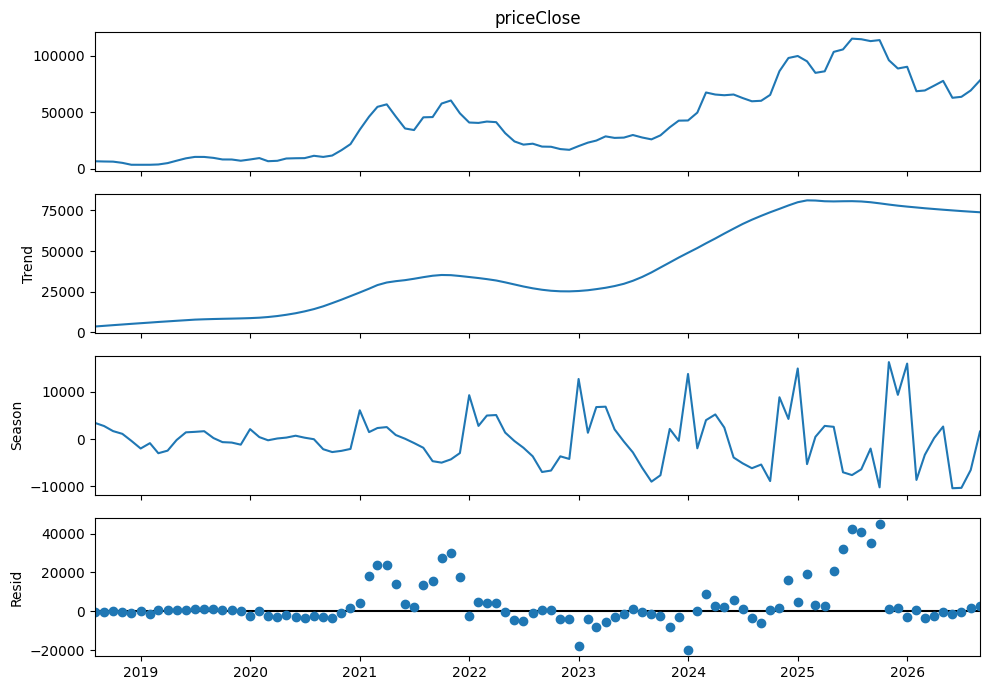

,tendencia_media,variacao_%
timeOpen,,
2018,4343.50,NaN
2019,7326.48,68.68
2020,13549.10,84.93
2021,31747.88,134.32
2022,29101.08,-8.34
2023,32883.83,13.00
2024,64427.83,95.93
2025,80099.78,24.32
2026,75491.65,-5.75


In [8]:
# T04 — Decomposição STL
def detectar_periodo_sazonal(serie, max_lag=None):
    """Lag de maior autocorrelação da série diferenciada (remove a tendência) — só para conferir SEASONAL_PERIODS.

    Na série original com tendência forte a ACF é máxima no lag 1, o que mascara a sazonalidade.
    """
    dif = serie.diff().dropna()
    max_lag = max_lag or len(dif) // 2
    valores = acf(dif, nlags=max_lag, fft=True)
    return int(np.argmax(valores[2:]) + 2)   # ignora lags 0 e 1


m_detectado = detectar_periodo_sazonal(y)
print(f'Período sazonal detectado pela ACF (m): {m_detectado}')
if m_detectado != SEASONAL_PERIODS:
    print(f'ATENÇÃO: SEASONAL_PERIODS={SEASONAL_PERIODS} difere do detectado ({m_detectado}). Revise a configuração.')

# Diagnóstico exploratório na série completa (não alimenta o ajuste dos modelos)
stl_res = STL(y, period=SEASONAL_PERIODS, robust=True).fit()
fig = stl_res.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

# Leitura numérica da tendência: alta / queda / estabilidade por ano
tend_anual = stl_res.trend.groupby(stl_res.trend.index.year).mean()
display(pd.DataFrame({'tendencia_media': tend_anual, 'variacao_%': tend_anual.pct_change() * 100}).round(2))

## T05 — Força da sazonalidade e resíduos

Cálculo da força da sazonalidade e análise do componente residual.

Força da sazonalidade: 0.000
Força da tendência:    0.876
Correlação amplitude sazonal × nível: 0.93 (perto de 1 => favorece sazonalidade multiplicativa)

Resíduo STL:


,resid
count,98.00
mean,3802.23
std,11535.50
min,-19814.68
25%,-2302.06
50%,613.78
75%,3671.47
max,44978.06


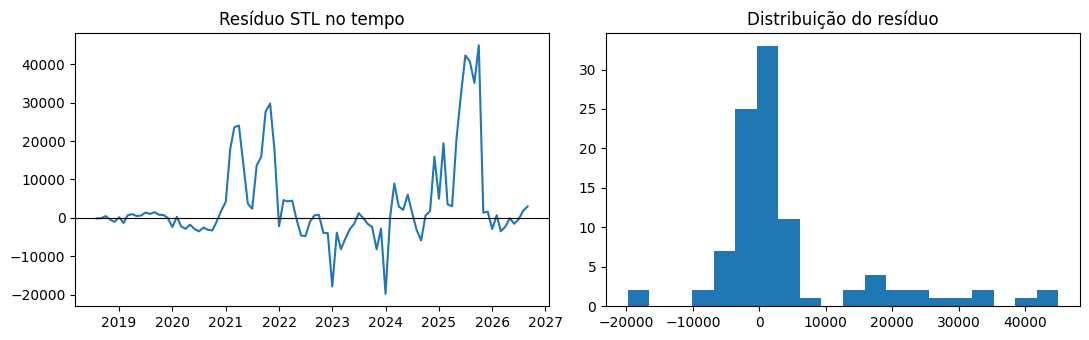

In [9]:
# T05 — Força da sazonalidade e resíduos
def forca(resid, componente):
    """Força (Hyndman): max(0, 1 - Var(R) / Var(componente + R)). Próxima de 1 => componente forte."""
    return max(0.0, 1 - np.var(resid) / np.var(componente + resid))


F_sazonal = forca(stl_res.resid, stl_res.seasonal)
F_tendencia = forca(stl_res.resid, stl_res.trend)
print(f'Força da sazonalidade: {F_sazonal:.3f}')
print(f'Força da tendência:    {F_tendencia:.3f}')

# Aditivo x multiplicativo: a amplitude sazonal cresce com o nível da série?
amplitude = stl_res.seasonal.groupby(stl_res.seasonal.index.year).agg(lambda s: s.max() - s.min())
nivel = stl_res.trend.groupby(stl_res.trend.index.year).mean()
print(f'Correlação amplitude sazonal × nível: {amplitude.corr(nivel):.2f} '
      '(perto de 1 => favorece sazonalidade multiplicativa)')

# Componente residual
print('\nResíduo STL:')
display(stl_res.resid.describe().round(2).to_frame('resid'))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(stl_res.resid)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_title('Resíduo STL no tempo')
ax[1].hist(stl_res.resid, bins=20)
ax[1].set_title('Distribuição do resíduo')
plt.tight_layout()
plt.show()

# 3. Validação temporal

## T08 — Validação walk-forward

Implementação do protocolo walk-forward com janelas, origens de teste fixas e horizonte de previsão unificado.

In [10]:
# T08 — Validação walk-forward (janela expansiva)
def make_origins(n_obs, horizon, n_origins, step):
    """Tamanhos de treino (origens). A última origem deixa exatamente `horizon` pontos para teste."""
    ultima = n_obs - horizon
    return [ultima - k * step for k in range(n_origins)][::-1]


def walk_forward(serie, forecast_fn, origins, horizon):
    """Para cada origem: ajusta só com o passado e prevê `horizon` passos à frente."""
    partes = []
    for o in origins:
        treino, teste = serie.iloc[:o], serie.iloc[o:o + horizon]
        prev = np.asarray(forecast_fn(treino, horizon))
        partes.append(pd.DataFrame({
            'origem': treino.index[-1], 'data': teste.index, 'h': np.arange(1, horizon + 1),
            'y_real': teste.values, 'y_prev': prev,
        }))
    return pd.concat(partes, ignore_index=True)


ORIGINS = make_origins(len(y), HORIZON, N_ORIGINS, ORIGIN_STEP)
assert ORIGINS[0] >= 2 * SEASONAL_PERIODS, (
    f'Treino da 1ª origem ({ORIGINS[0]}) menor que 2 ciclos sazonais — reduza N_ORIGINS/ORIGIN_STEP.')

# Hold-out simples = última origem (mesmo split do notebook de referência)
train, test = y.iloc[:ORIGINS[-1]], y.iloc[ORIGINS[-1]:]

display(pd.DataFrame([{
    'fold': i + 1, 'n_treino': o, 'treino_ate': y.index[o - 1].date(),
    'teste_de': y.index[o].date(), 'teste_ate': y.index[o + HORIZON - 1].date(),
} for i, o in enumerate(ORIGINS)]))

,fold,n_treino,treino_ate,teste_de,teste_ate
0,1,62,2023-09-01,2023-10-01,2024-09-01
1,2,74,2024-09-01,2024-10-01,2025-09-01
2,3,86,2025-09-01,2025-10-01,2026-09-01


# 4. Modelagem Holt-Winters

## T09 — Holt-Winters

Adaptação do Holt-Winters com ajuste de tendência, sazonalidade, parâmetros alpha, beta e gamma e execução walk-forward.

,alpha,beta,gamma,phi,AIC,BIC,MAE_holdout
modelo,,,,,,,
SES (sem tend./saz.),1.0,NaN,NaN,NaN,1497.9467,1502.8554,33779.9662
HW aditivo,1.0,0.0304,0.0,NaN,1524.3045,1563.5741,49216.3940
HW multiplicativo,1.0,0.0180,0.0,NaN,1539.2681,1578.5377,53312.1701
HW multiplicativo amortecido,1.0,0.0220,0.0,0.995,1541.4468,1583.1707,53646.1821


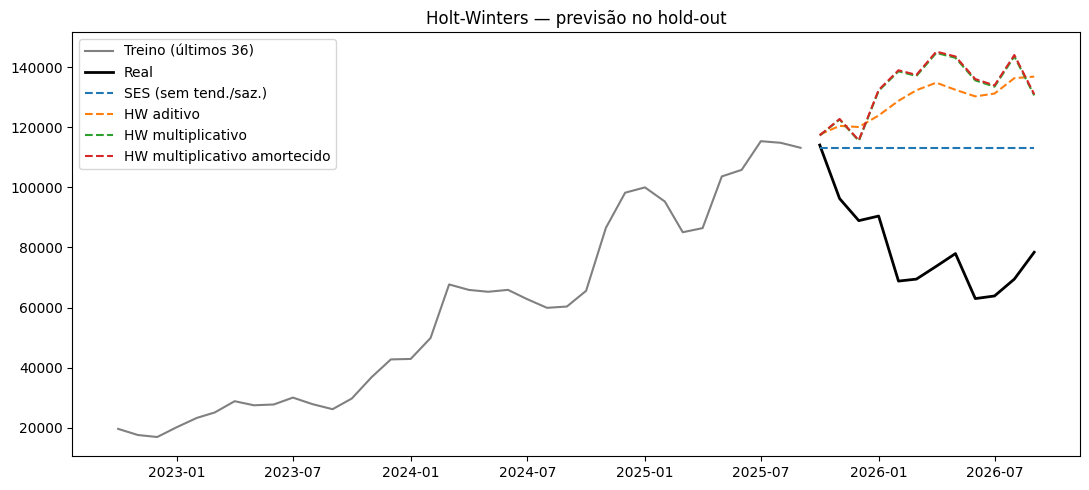

In [11]:
# T09 — Holt-Winters (SES, aditivo, multiplicativo e multiplicativo amortecido)
def ajustar_hw(treino, trend=TREND, seasonal=SEASONAL, damped=DAMPED_TREND, **fit_kwargs):
    modelo = ExponentialSmoothing(
        treino,
        trend=trend,
        damped_trend=bool(damped and trend),
        seasonal=seasonal,
        seasonal_periods=SEASONAL_PERIODS if seasonal else None,
        initialization_method=INITIALIZATION_METHOD,
        use_boxcox=USE_BOXCOX,
    )
    return modelo.fit(optimized=OPTIMIZED, **fit_kwargs)


def parametros(fit):
    p = fit.params
    beta = p.get('smoothing_trend', p.get('smoothing_slope'))
    return {'alpha': p.get('smoothing_level'), 'beta': beta,
            'gamma': p.get('smoothing_seasonal'), 'phi': p.get('damping_trend')}


MODELOS_HW = {
    'SES (sem tend./saz.)':        dict(trend=None,  seasonal=None,  damped=False),
    'HW aditivo':                  dict(trend='add', seasonal='add', damped=False),
    'HW multiplicativo':           dict(trend='add', seasonal='mul', damped=False),
    'HW multiplicativo amortecido': dict(trend='add', seasonal='mul', damped=True),
}


def hw_forecaster(kw):
    return lambda treino, h: ajustar_hw(treino, **kw).forecast(h)


# 1) Walk-forward (previsões fora da amostra) — alimenta T16/T17
wf_resultados = {nome: walk_forward(y, hw_forecaster(kw), ORIGINS, HORIZON) for nome, kw in MODELOS_HW.items()}

# 2) Ajuste no treino do hold-out (última origem): parâmetros e critérios de informação
fits_holdout = {nome: ajustar_hw(train, **kw) for nome, kw in MODELOS_HW.items()}
linhas = []
for nome, fit in fits_holdout.items():
    linhas.append({'modelo': nome, **parametros(fit), 'AIC': fit.aic, 'BIC': fit.bic,
                   'MAE_holdout': mean_absolute_error(test, fit.forecast(HORIZON))})
display(pd.DataFrame(linhas).set_index('modelo').round(4))

# 3) Previsões do hold-out
plt.figure(figsize=(11, 5))
plt.plot(train.index[-36:], train.values[-36:], color='gray', label='Treino (últimos 36)')
plt.plot(test.index, test.values, color='black', lw=2, label='Real')
for nome, fit in fits_holdout.items():
    plt.plot(test.index, fit.forecast(HORIZON), ls='--', label=nome)
plt.legend()
plt.title('Holt-Winters — previsão no hold-out')
plt.tight_layout()
plt.show()

### Sensibilidade da tendência amortecida (φ)

Sem amortecimento a tendência é somada linearmente e a previsão diverge com o horizonte. Com ``damped_trend=True`` cada passo
futuro da tendência é multiplicado por uma potência de φ (0 < φ < 1). Compara-se φ estimado por MLE com φ fixo, em um horizonte longo.

,phi,valor_ultimo_mes,variacao_%_vs_sem_damping,AIC
0,sem damping,188894.68,0.00,1499.63
1,MLE (0.8000),109603.05,-41.98,1496.94
2,0.99,177469.05,-6.05,1501.63
3,0.95,143679.70,-23.94,1501.18
4,0.9,126980.11,-32.78,1500.68
5,0.85,109961.61,-41.79,1499.85
6,0.8,109603.05,-41.98,1496.94
7,0.7,110126.68,-41.70,1492.11


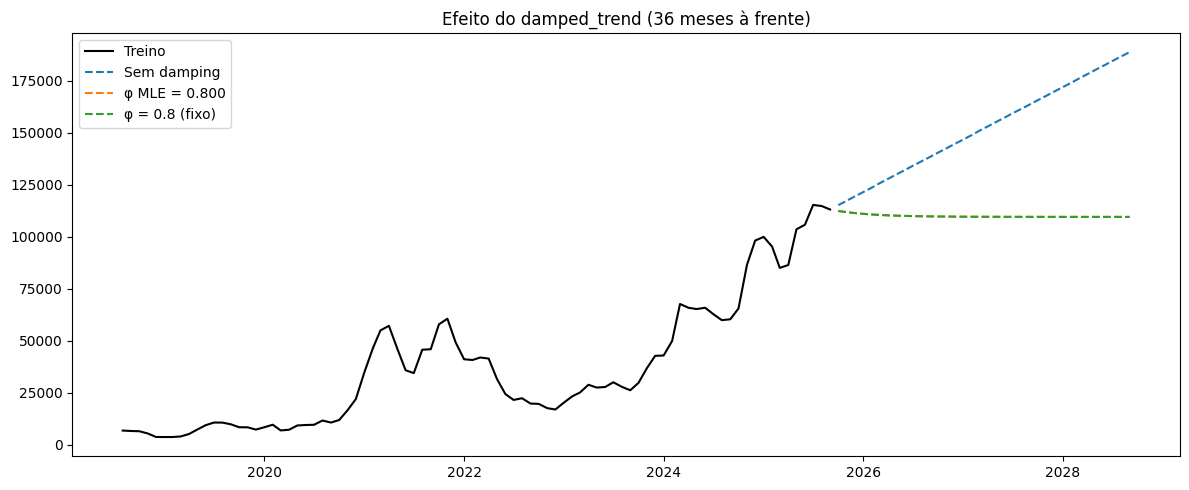

In [12]:
sem_damping = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=False)
mle = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=True)
phi_mle = parametros(mle)['phi']

fc_base = sem_damping.forecast(LONG_HORIZON)
fc_mle = mle.forecast(LONG_HORIZON)
valor_base = fc_base.iloc[-1]

linhas = [
    {'phi': 'sem damping', 'valor_ultimo_mes': valor_base, 'variacao_%_vs_sem_damping': 0.0, 'AIC': sem_damping.aic},
    {'phi': f'MLE ({phi_mle:.4f})', 'valor_ultimo_mes': fc_mle.iloc[-1],
     'variacao_%_vs_sem_damping': (fc_mle.iloc[-1] / valor_base - 1) * 100, 'AIC': mle.aic},
]
fc_fixos = {}
for phi in DAMPING_GRID:
    fit = ajustar_hw(train, trend='add', seasonal=SEASONAL, damped=True, damping_trend=phi)
    fc_fixos[phi] = fit.forecast(LONG_HORIZON)
    linhas.append({'phi': phi, 'valor_ultimo_mes': fc_fixos[phi].iloc[-1],
                   'variacao_%_vs_sem_damping': (fc_fixos[phi].iloc[-1] / valor_base - 1) * 100, 'AIC': fit.aic})
display(pd.DataFrame(linhas).round(2))

phi_plot = 0.80 if 0.80 in fc_fixos else DAMPING_GRID[-1]
plt.figure(figsize=(12, 5))
plt.plot(train.index, train.values, color='black', label='Treino')
plt.plot(fc_base.index, fc_base.values, ls='--', label='Sem damping')
plt.plot(fc_mle.index, fc_mle.values, ls='--', label=f'φ MLE = {phi_mle:.3f}')
plt.plot(fc_fixos[phi_plot].index, fc_fixos[phi_plot].values, ls='--', label=f'φ = {phi_plot} (fixo)')
plt.legend()
plt.title(f'Efeito do damped_trend ({LONG_HORIZON} meses à frente)')
plt.tight_layout()
plt.show()

### Modelo de referência — SARIMA (grid search)

Mesmo grid do notebook de referência (p,d,q ∈ 0–2; P,D,Q ∈ 0–1; m = ``SEASONAL_PERIODS``), escolhido por **AIC**.
Para não vazar informação do futuro, o grid é feito só com o treino da **primeira origem** e a ordem escolhida fica congelada
para todos os folds (no notebook de referência o MAE do teste também era calculado dentro do grid; aqui ele não entra na escolha).

In [13]:
if RUN_SARIMA:
    pdq = list(itertools.product(range(0, 3), range(0, 3), range(0, 3)))
    sazonal_pdq = [(P, D, Q, SEASONAL_PERIODS) for P, D, Q in itertools.product(range(0, 2), range(0, 2), range(0, 2))]
    treino_grid = y.iloc[:ORIGINS[0]]

    resultados = []
    for order in pdq:
        for seasonal_order in sazonal_pdq:
            try:
                res = SARIMAX(treino_grid, order=order, seasonal_order=seasonal_order,
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                resultados.append({'order': order, 'seasonal_order': seasonal_order, 'AIC': res.aic, 'BIC': res.bic})
            except Exception:
                continue

    grid_sarima = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
    display(grid_sarima.head(10))
    melhor = grid_sarima.iloc[0]
    print(f"Escolhido: order={melhor['order']}, seasonal_order={melhor['seasonal_order']}")

    def sarima_forecaster(treino, h):
        return SARIMAX(treino, order=melhor['order'], seasonal_order=melhor['seasonal_order'],
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False).forecast(h)

    wf_resultados['SARIMA (grid AIC)'] = walk_forward(y, sarima_forecaster, ORIGINS, HORIZON)

,order,seasonal_order,AIC,BIC
0,"(0, 1, 2)","(0, 1, 1, 12)",686.698771,692.804213
1,"(1, 1, 2)","(0, 1, 1, 12)",688.532890,696.164693
2,"(0, 1, 2)","(1, 1, 1, 12)",688.685428,696.317230
3,"(2, 1, 2)","(0, 1, 1, 12)",689.568628,698.726791
4,"(1, 1, 2)","(1, 1, 1, 12)",690.525616,699.683779
5,"(2, 1, 2)","(1, 1, 1, 12)",691.567131,702.251654
6,"(2, 2, 1)","(1, 1, 0, 12)",696.907902,704.539705
7,"(2, 2, 2)","(1, 1, 0, 12)",697.890267,707.048430
8,"(2, 2, 0)","(1, 1, 0, 12)",704.252269,710.357711
9,"(0, 1, 1)","(0, 1, 1, 12)",705.453876,710.119920


Escolhido: order=(0, 1, 2), seasonal_order=(0, 1, 1, 12)


# 5. Avaliação

## T16 — Comparação por MAE

Consolidação do MAE fora da amostra por base e modelo, incluindo número de vitórias e posição média.

MAE por fold:


,SES (sem tend./saz.),HW aditivo,HW multiplicativo,HW multiplicativo amortecido,SARIMA (grid AIC)
fold 1 (origem 2023-09),27970.51,26461.45,17700.66,22347.99,23192.03
fold 2 (origem 2024-09),37143.37,32466.46,30197.68,30823.10,30451.15
fold 3 (origem 2025-09),33779.97,49216.39,53312.17,53646.18,36357.73


Resumo:


,base,MAE_medio,MAE_ultimo_fold,vitorias,posicao_media
HW multiplicativo,bitcoin.xlsx,33736.84,53312.17,2,2.00
SARIMA (grid AIC),bitcoin.xlsx,30000.30,36357.73,0,2.33
HW multiplicativo amortecido,bitcoin.xlsx,35605.76,53646.18,0,3.33
SES (sem tend./saz.),bitcoin.xlsx,32964.61,33779.97,1,3.67
HW aditivo,bitcoin.xlsx,36048.10,49216.39,0,3.67


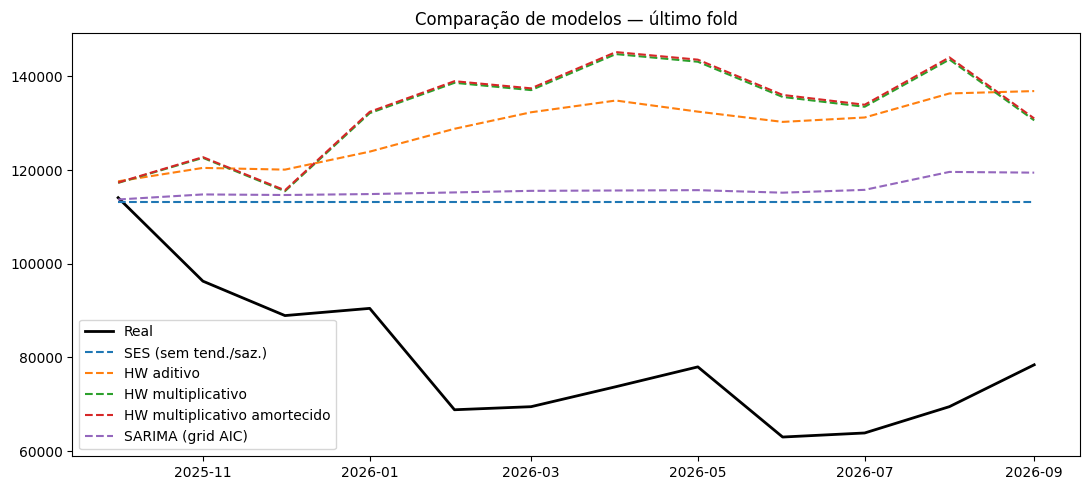

In [14]:
# T16 — Comparação por MAE (fora da amostra, walk-forward)
tabela_mae = pd.DataFrame({
    nome: {origem: mean_absolute_error(d['y_real'], d['y_prev']) for origem, d in df_wf.groupby('origem')}
    for nome, df_wf in wf_resultados.items()
})
tabela_mae.index = [f'fold {i + 1} (origem {o:%Y-%m})' for i, o in enumerate(tabela_mae.index)]
print('MAE por fold:')
display(tabela_mae.round(2))

posicoes = tabela_mae.rank(axis=1, method='min')          # 1 = melhor no fold
resumo = pd.DataFrame({
    'base': DATA_FILENAME,
    'MAE_medio': tabela_mae.mean(),
    'MAE_ultimo_fold': tabela_mae.iloc[-1],
    'vitorias': (posicoes == 1).sum(),
    'posicao_media': posicoes.mean(),
}).sort_values(['posicao_media', 'MAE_medio'])
print('Resumo:')
display(resumo.round(2))

# Gráfico do último fold (= hold-out do notebook de referência)
ultimo = next(iter(wf_resultados.values()))['origem'].max()
plt.figure(figsize=(11, 5))
plt.plot(test.index, test.values, color='black', lw=2, label='Real')
for nome, df_wf in wf_resultados.items():
    d = df_wf[df_wf['origem'] == ultimo]
    plt.plot(d['data'], d['y_prev'], ls='--', label=nome)
plt.legend()
plt.title('Comparação de modelos — último fold')
plt.tight_layout()
plt.show()

## T17 — Diagnóstico dos resíduos

Análise gráfica e estatística dos resíduos com série temporal dos erros, ACF, teste de Ljung-Box e tabela de p-valores.

Modelo configurado: trend=add, seasonal=None, damped=True | n resíduos = 86


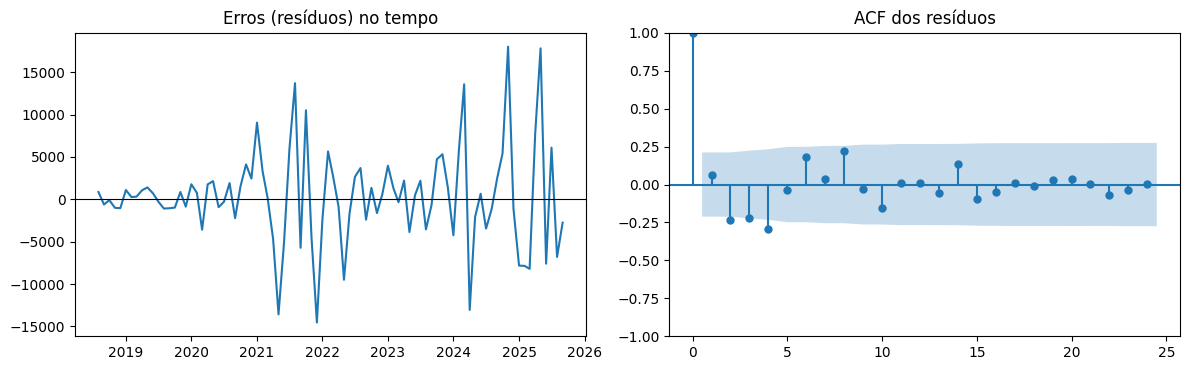

p-valores do teste de Ljung-Box:


,lag 6,lag 12,lag 24
SES (sem tend./saz.),0.0000,0.0001,0.0060
HW aditivo,0.0000,0.0000,0.0002
HW multiplicativo,0.0010,0.0021,0.0533
HW multiplicativo amortecido,0.0009,0.0020,0.0524


In [15]:
# T17 — Diagnóstico dos resíduos (modelo configurado + candidatos)
fit_cfg = ajustar_hw(train)            # usa TREND / SEASONAL / DAMPED_TREND da configuração
resid = fit_cfg.resid
print(f'Modelo configurado: trend={TREND}, seasonal={SEASONAL}, damped={DAMPED_TREND} | n resíduos = {len(resid)}')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(resid)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_title('Erros (resíduos) no tempo')
plot_acf(resid, lags=min(24, len(resid) // 2 - 1), ax=ax[1])
ax[1].set_title('ACF dos resíduos')
plt.tight_layout()
plt.show()

# Ljung-Box (H0: resíduos sem autocorrelação; p < 0.05 => rejeita H0)
LAGS = [l for l in (6, 12, 24) if l <= len(resid) // 3]
tabela_lb = pd.DataFrame({
    nome: acorr_ljungbox(fit.resid, lags=LAGS, return_df=True)['lb_pvalue']
    for nome, fit in fits_holdout.items()
}).T
tabela_lb.columns = [f'lag {l}' for l in LAGS]
print('p-valores do teste de Ljung-Box:')
display(tabela_lb.round(4))

# Checklist antes do commit

- [ ] Configuração e versão da execução atualizadas.
- [ ] Separação temporal e horizonte documentados.
- [ ] Transformadores ajustados somente com dados de treino.
- [ ] Hiperparâmetros congelados antes do teste final.
- [ ] Métricas calculadas com previsões fora da amostra.
- [ ] Artefatos essenciais salvos por tarefa.
- [ ] Saídas excessivas e células temporárias removidas.